In [2]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import matplotlib.pyplot as plt
from matplotlib import patches
import pandas as pd
from astropy.table import Table
import synthpop as sp

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [3]:
ap_tab = Table.read('data/apjac8bd6/apjac8bd6t3_mrt.txt', format="ascii.cds")
ap_tab

Name,F127M,e_F127M,F139M,e_F139M,F153M,e_F153M,dRA,e_dRA,dDE,e_dDE,pmRA,e_pmRA,pmDE,e_pmDE,t0,Nobs,chi2RA,chi2DE,Pclust
,mag,mag,mag,mag,mag,mag,arcsec,arcsec,arcsec,arcsec,mas / yr,mas / yr,mas / yr,mas / yr,yr,,,,
str8,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64
A0000001,11.41,0.02,11.12,0.01,10.81,0.02,-11.38042,0.00024,-2.89786,0.00023,0.23,0.11,-1.01,0.1,2013.025,4,0.46,0.06,0.0
A0000002,11.41,0.01,11.13,0.01,10.85,0.01,36.87441,0.00025,26.16057,0.00024,0.17,0.11,-4.78,0.1,2012.939,4,1.69,0.85,0.0
A0000003,11.85,0.03,11.53,0.02,11.15,0.02,-92.22162,0.0004,-6.60737,0.00054,2.41,0.16,-0.55,0.2,2013.4949,4,0.11,0.54,0.0
A0000004,14.27,0.01,13.6,0.01,11.73,0.01,-84.04126,0.00033,-15.9848,0.00048,-0.53,0.13,-2.65,0.18,2013.5663,4,0.13,0.23,0.0
A0000005,12.43,0.01,12.1,0.01,11.76,0.01,0.49685,0.00018,-21.671,0.00016,-2.8,0.08,-3.48,0.06,2013.0293,4,0.33,0.38,0.0
A0000006,14.79,0.01,13.63,0.01,12.33,0.01,30.47736,0.00016,-0.49717,0.00014,-7.06,0.07,-4.44,0.06,2012.8629,4,0.05,1.38,0.0
A0000007,14.59,0.01,13.48,0.01,12.37,0.01,-3.08627,0.00019,-2.77484,0.00017,-0.77,0.08,-1.92,0.07,2013.1023,4,0.95,0.63,0.94
A0000008,14.13,0.01,13.29,0.01,12.4,0.01,-24.85458,0.00035,49.91354,0.00028,1.72,0.13,1.34,0.1,2013.3322,4,0.46,0.37,0.0


In [4]:
tab0 = ap_tab[ap_tab['Pclust']<0.5].to_pandas()

In [5]:
# mod = 0
# mod = sp.SynthPop(default_config='huston2025_defaults.synthpop_conf',
#                           model_name="Huston2025", name_for_output='arches',
#                           chosen_bands=["WFC3_IR_F127M", "WFC3_IR_F139M", "WFC3_IR_F153M"],
#                          maglim=['WFC3_IR_F153M', 99, "remove"], output_location="outputfiles/arches",
#                          skip_lowmass_stars=True)
# mod.init_populations()

In [6]:
from mulens_rates import misc_utils

In [7]:
rd_coord = SkyCoord(ra='17:45:50.65020', dec='−28:49:19.51468', unit=(u.hourangle, u.degree))
coord = rd_coord.transform_to('galactic')
print(coord)
coord
solang = (132*124)/60**4
solang

<SkyCoord (Galactic): (l, b) in deg
    (0.12295853, 0.01752085)>


0.001262962962962963

In [10]:
#sp_tab,_ = mod.process_location(l_deg=coord.l.degree, b_deg=coord.b.degree, solid_angle=solang)
sp_tab = pd.read_csv("outputfiles/arches/arches_l0.123_b0.018.csv")

In [15]:
tb = sp_tab[sp_tab["WFC3_IR_F153M"]<30]
len(tb)/(solang*60**4) * np.pi*(0.13/2)**2

3.5470668976323734

In [17]:
tab_bl = misc_utils.calc_blends(sp_tab[sp_tab["WFC3_IR_F153M"]<30], 
                                filters=["WFC3_IR_F127M", "WFC3_IR_F139M", "WFC3_IR_F153M"],
                                blend_rad=0.16/2/3600)
tab_bl.to_csv(f'outputfiles/arches/blended_arches.csv', index=False)

  0%|          | 0/4374097 [00:00<?, ?it/s]

In [18]:
tab_bl = pd.read_csv('outputfiles/arches/blended_arches.csv')

In [7]:
tab = tab0
tab

,Name,F127M,e_F127M,F139M,e_F139M,F153M,e_F153M,dRA,e_dRA,dDE,e_dDE,pmRA,e_pmRA,pmDE,e_pmDE,t0,Nobs,chi2RA,chi2DE,Pclust
0,A0000001,11.41,0.02,11.12,0.01,10.81,0.02,-11.38042,0.00024,-2.89786,0.00023,0.23,0.11,-1.01,0.10,2013.0250,4,0.46,0.06,0.00
1,A0000002,11.41,0.01,11.13,0.01,10.85,0.01,36.87441,0.00025,26.16057,0.00024,0.17,0.11,-4.78,0.10,2012.9390,4,1.69,0.85,0.00
2,A0000003,11.85,0.03,11.53,0.02,11.15,0.02,-92.22162,0.00040,-6.60737,0.00054,2.41,0.16,-0.55,0.20,2013.4949,4,0.11,0.54,0.00
3,A0000004,14.27,0.01,13.60,0.01,11.73,0.01,-84.04126,0.00033,-15.98480,0.00048,-0.53,0.13,-2.65,0.18,2013.5663,4,0.13,0.23,0.00
4,A0000005,12.43,0.01,12.10,0.01,11.76,0.01,0.49685,0.00018,-21.67100,0.00016,-2.80,0.08,-3.48,0.06,2013.0293,4,0.33,0.38,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33694,A0034596,25.31,0.70,25.03,0.00,24.33,0.67,10.67118,0.00327,-37.18946,0.00327,-0.10,1.21,-3.43,1.22,2013.0761,4,1.57,0.13,0.08
33695,A0034597,25.40,0.74,24.53,0.70,24.35,0.69,-1.47663,0.00326,-51.79634,0.00326,-4.13,1.26,-8.44,1.26,2013.0078,4,0.18,5.45,0.00
33696,A0034598,24.72,0.84,25.03,1.51,24.40,0.82,-32.21548,0.00317,5.29918,0.00318,-4.21,1.38,-7.22,1.38,2012.8530,4,1.28,6.61,0.00
33697,A0034599,NaN,NaN,NaN,NaN,24.48,0.84,-28.83829,0.00373,39.49033,0.00372,-4.02,1.26,-1.45,1.26,2013.3073,3,0.14,1.67,0.02


In [8]:
tab_coords = SkyCoord(ra=rd_coord.ra+tab.dRA.to_numpy()/np.cos(rd_coord.dec.rad)*u.arcsec, 
                      dec=rd_coord.dec+tab.dDE.to_numpy()*u.arcsec, 
                      pm_ra_cosdec=tab.pmRA.to_numpy()*u.mas/u.year, 
                      pm_dec=tab.pmDE.to_numpy()*u.mas/u.year).transform_to('galactic')

In [10]:
sp_tab_nn = sp_tab[sp_tab['pop']!=2.0]

/var/folders/_z/fn__fgrs2wqgsmbvw8bvrr0r0000gn/T/ipykernel_91014/33769698.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[1][i].errorbar(bins[:-1]+np.diff(bins)/2, spcts/cts, yerr=spcts/cts*np.sqrt(cts)/cts,
/var/folders/_z/fn__fgrs2wqgsmbvw8bvrr0r0000gn/T/ipykernel_91014/33769698.py:11: RuntimeWarning: invalid value encountered in multiply
  ax[1][i].errorbar(bins[:-1]+np.diff(bins)/2, spcts/cts, yerr=spcts/cts*np.sqrt(cts)/cts,


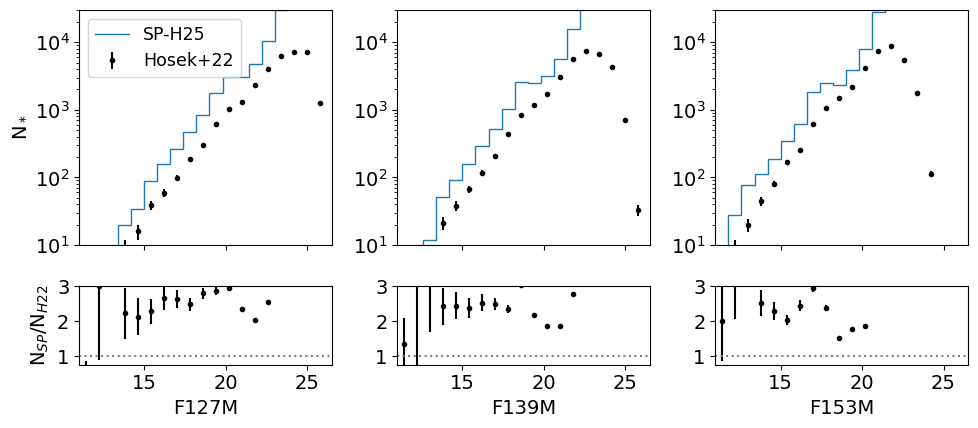

In [11]:
plt.rcParams.update({'font.size': 14})
fig,ax = plt.subplots(nrows=2,ncols=3, figsize=(10,4.5), height_ratios=[3,1], sharex=True)
filts = [127,139,153]
for i in range(len(filts)):
    cts,bins = np.histogram(tab[f'F{filts[i]}M'], bins=np.linspace(11,27, 21))
    ax[0][i].errorbar(bins[:-1]+np.diff(bins)/2, cts, yerr=np.sqrt(cts), label='Hosek+22',
                     linestyle='none', marker='.', c='k')
    spcts,bins = np.histogram(sp_tab[f'WFC3_IR_F{filts[i]}M'], bins=bins)
    spcts_nn,bins = np.histogram(sp_tab_nn[f'WFC3_IR_F{filts[i]}M'], bins=bins)
    ax[0][i].stairs(spcts, bins, label='SP-H25')
    ax[1][i].errorbar(bins[:-1]+np.diff(bins)/2, spcts/cts, yerr=spcts/cts*np.sqrt(cts)/cts,
                     linestyle='none', marker='.', c='k')
    ax[1][i].set_ylim(0.75,3.0)
    ax[1][i].axhline([1], c='gray', linestyle=':')
    #ax[0][i].stairs(spcts_nn, bins, label='SP-H25\nNo NSD')
    ax[0][i].set_yscale('log')
    ax[1][i].set_xlabel(f'F{filts[i]}M')
    ax[0][i].set_xlim(11,26.5)
    ax[0][i].set_ylim(10, 3e4)
ax[0][0].set_ylabel(r'N$_*$')
ax[1][0].set_ylabel(r'N$_{SP}$/N$_{H22}$')
ax[0][0].legend(fontsize=12.5, frameon=True)
fig.tight_layout()
fig.savefig('figures/nsd_aches_lf_hosek22.png')
fig.savefig('figures/nsd_arches_lf_hosek22.pdf')

NameError: name 'tab' is not defined

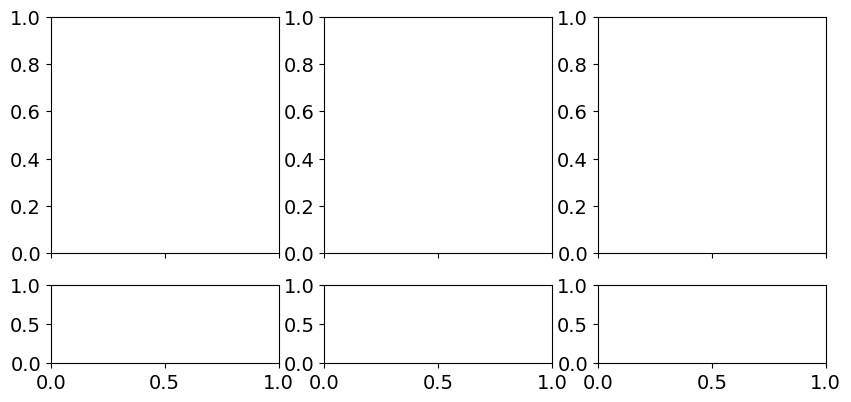

In [19]:
plt.rcParams.update({'font.size': 14})
fig,ax = plt.subplots(nrows=2,ncols=3, figsize=(10,4.5), height_ratios=[3,1], sharex=True)
filts = [127,139,153]
for i in range(len(filts)):
    cts,bins = np.histogram(tab[f'F{filts[i]}M'], bins=np.linspace(11,27, 21))
    ax[0][i].errorbar(bins[:-1]+np.diff(bins)/2, cts, yerr=np.sqrt(cts), label='Hosek+22',
                     linestyle='none', marker='.', c='k')
    spcts,bins = np.histogram(tab_bl[f'WFC3_IR_F{filts[i]}M'], bins=bins)
    ax[0][i].stairs(spcts, bins, label='SP-H25')
    ax[1][i].errorbar(bins[:-1]+np.diff(bins)/2, spcts/cts, yerr=spcts/cts*np.sqrt(cts)/cts,
                     linestyle='none', marker='.', c='k')
    ax[1][i].set_ylim(0.75,3.0)
    ax[1][i].axhline([1], c='gray', linestyle=':')
    #ax[0][i].stairs(spcts_nn, bins, label='SP-H25\nNo NSD')
    ax[0][i].set_yscale('log')
    ax[1][i].set_xlabel(f'F{filts[i]}M')
    ax[0][i].set_xlim(11,26.5)
    ax[0][i].set_ylim(10, 3e4)
ax[0][0].set_ylabel(r'N$_*$')
ax[1][0].set_ylabel(r'N$_{SP}$/N$_{H22}$')
ax[0][0].legend(fontsize=12.5, frameon=True)
fig.tight_layout()
fig.savefig('figures/nsd_aches_lf_hosek22_bl.png')
fig.savefig('figures/nsd_arches_lf_hosek22_bl.pdf')

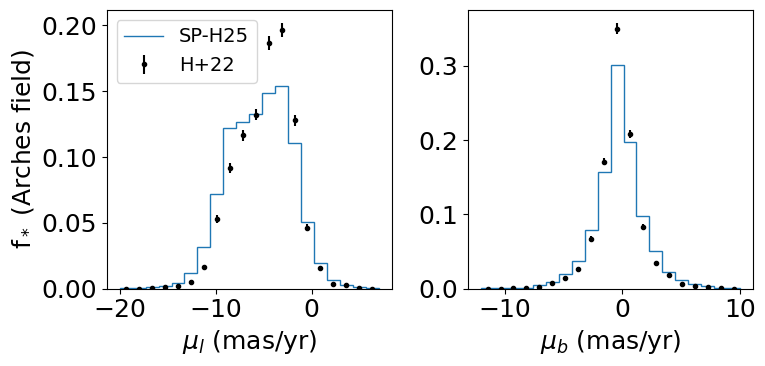

In [17]:
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

sp_tab_cut = sp_tab[sp_tab['WFC3_IR_F153M']<20]
sp_tab_nn_cut = sp_tab_nn[sp_tab_nn['WFC3_IR_F153M']<20]
cts_mul, bins = np.histogram(tab_coords.pm_l_cosb.value[tab['F153M']<20], bins=np.linspace(-20,7, 21))
ax[0].errorbar(bins[:-1]+np.diff(bins)/2, cts_mul/np.sum(cts_mul), yerr=np.sqrt(cts_mul)/np.sum(cts_mul), 
               label="H+22", c='k', marker='.', linestyle='none')
n_obs = sum(cts_mul)
sp_cts_mul,_ = np.histogram(sp_tab_cut['mul'], bins=bins)
ax[0].stairs(sp_cts_mul/np.sum(sp_cts_mul), bins, label='SP-H25')
sp_cts_mul_nn,_ = np.histogram(sp_tab_nn_cut['mul'], bins=bins)
#ax[0].stairs(sp_cts_mul_nn/np.sum(sp_cts_mul_nn), bins, label='SP-H25\nNo NSD')
ax[0].set_xlabel(r'$\mu_l$ (mas/yr)')
ax[0].set_ylabel(r'f$_*$ (Arches field)')
#ax[0].legend()
#ax[0].set_xlim(-22,6)

cts_mub, bins = np.histogram(tab_coords.pm_b.value[tab['F153M']<20], bins=np.linspace(-12,10, 21))
ax[1].errorbar(bins[:-1]+np.diff(bins)/2, cts_mub/np.sum(cts_mub), yerr=np.sqrt(cts_mub)/np.sum(cts_mub), 
               label="H+22", c='k', marker='.', linestyle='none')
n_obs = sum(cts_mub)
sp_cts_mub,_ = np.histogram(sp_tab_cut.mub, bins=bins)
ax[1].stairs(sp_cts_mub/np.sum(sp_cts_mub), bins, label='SP-H25')
sp_cts_mub_nn,_ = np.histogram(sp_tab_nn_cut['mub'], bins=bins)
#ax[1].stairs(sp_cts_mub_nn/np.sum(sp_cts_mub_nn), bins, label='SP-H25\nNo NSD')
ax[1].set_xlabel(r'$\mu_b$ (mas/yr)')
ax[0].legend(fontsize=14)
fig.tight_layout()
fig.savefig('figures/nsd_arches_pm_hosek22.png')
fig.savefig('figures/nsd_arches_pm_hosek22.pdf')